In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [3]:
df= pd.read_csv(r'F:\AI-ML-BootCamp\NETSOL WORK\Week_4\titanic_dataset.csv')

In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df = df.rename(columns={'survived': 'Survived'})

In [10]:
survived_count = df['Survived'].sum()     
total          = df['Survived'].count()  

p_survive = survived_count / total 

In [11]:
Mean = df['Survived'].mean()
print(f"Probability of survival (P(Survived=1)): {p_survive:.4f}")
print(f"Total passengers: {len(df)}")
print(f"Number of survivors: {df['Survived'].sum()}")

print(f"P(Survived=1) = {p_survive:.4f}") 
print(f"P(Died=0)     = {1-p_survive:.4f}")


Probability of survival (P(Survived=1)): 0.3838
Total passengers: 891
Number of survivors: 342
P(Survived=1) = 0.3838
P(Died=0)     = 0.6162


P(X=1) = 0.3838
P(X=0) = 0.6162
Mean   = 0.3838
Variance = 0.2365


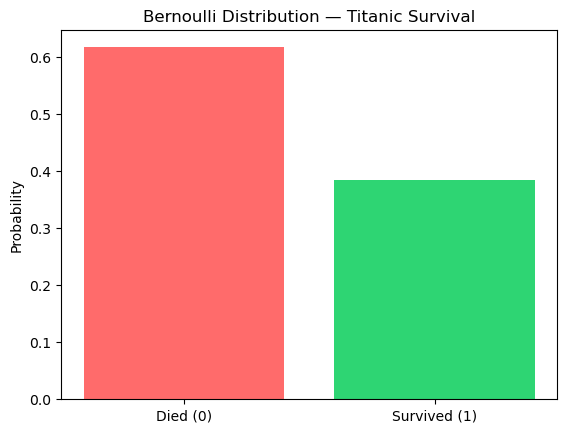

In [12]:

bern = stats.bernoulli(p_survive)

# Probabilities
print(f"P(X=1) = {bern.pmf(1):.4f}")  
print(f"P(X=0) = {bern.pmf(0):.4f}")
print(f"Mean   = {bern.mean():.4f}")    
print(f"Variance = {bern.var():.4f}")  

# Bar chart plot
plt.bar(['Died (0)', 'Survived (1)'],
        [1 - p_survive, p_survive],
        color=['#ff6b6b', '#2ed573'])
plt.title('Bernoulli Distribution — Titanic Survival')
plt.ylabel('Probability')
plt.show()

In [13]:

samples = bern.rvs(1000)

print(f"Simulated survivors: {samples.sum()} out of 1000")
print(f"Simulated rate: {samples.mean():.4f} (actual: {p_survive:.4f})")

Simulated survivors: 386 out of 1000
Simulated rate: 0.3860 (actual: 0.3838)


In [27]:
df.columns

Index(['Survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone', 'Sex_binary'],
      dtype='object')

In [28]:
survivors = df[df['Survived'] == 1]
non_survivors = df[df['Survived'] == 0]

In [30]:
gender_counts = survivors['sex'].value_counts()

male_survived = gender_counts['male']
female_survived = gender_counts['female']

total_survived = len(survivors)

In [32]:
p_male_survived = male_survived / total_survived
p_female_survived = female_survived / total_survived

print(f"P(Male Survived) = {p_male_survived:.4f}")
print(f"P(Female Survived) = {p_female_survived:.4f}")

P(Male Survived) = 0.3187
P(Female Survived) = 0.6813


In [33]:
print(f"Total survivors: {total_survived}")
print(f"Male survivors: {male_survived}")
print(f"Female survivors: {female_survived}")

print(f"P(Male | Survived)   = {p_male_survived:.4f}")
print(f"P(Female | Survived) = {p_female_survived:.4f}")

Total survivors: 342
Male survivors: 109
Female survivors: 233
P(Male | Survived)   = 0.3187
P(Female | Survived) = 0.6813


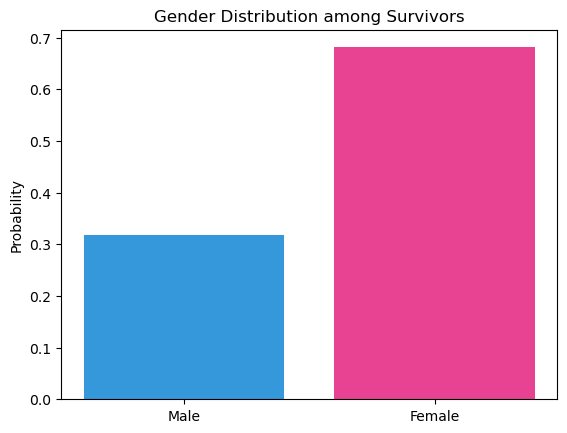

In [34]:
import matplotlib.pyplot as plt

plt.bar(['Male', 'Female'],
        [p_male_survived, p_female_survived],
        color=['#3498db', '#e84393'])

plt.title('Gender Distribution among Survivors')
plt.ylabel('Probability')
plt.show()

Binomial distribution

In [57]:
p = df['Survived'].mean()   # 0.3838
n = 10                       # 10 passengers
print(f"n = {n}, p = {p:.4f}")

n = 10, p = 0.3838


In [59]:
# Binomial distribution 
binom = stats.binom(n, p)

# Basic stats
print(f"Mean     = nxp     = {binom.mean():.4f}")   
print(f"Variance = nxpx(1-p) = {binom.var():.4f}") 

Mean     = nxp     = 3.8384
Variance = nxpx(1-p) = 2.3651


In [61]:
# Exactly 4 logo ke bachne ki probability
print(f"P(X=4)  = {binom.pmf(4):.4f}")
# less then 4 
print(f"P(X<4)  = {binom.cdf(3):.4f}")

# 1 0r more then 1
print(f"P(X>=1) = {1 - binom.pmf(0):.4f}")


P(X=4)  = 0.2494
P(X<4)  = 0.4236
P(X>=1) = 0.9921


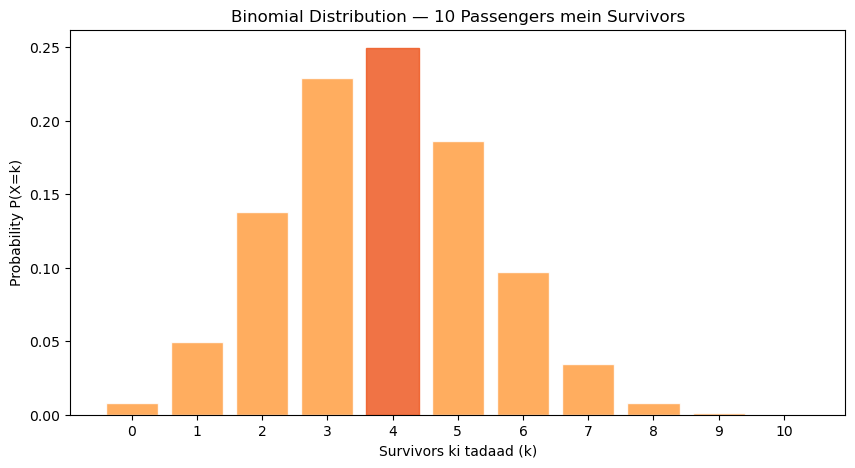

In [ ]:
k_values = np.arange(0, n+1)          
probs    = binom.pmf(k_values)       

plt.figure(figsize=(10, 5))
bars = plt.bar(k_values, probs,
               color='#ff9f43',
               edgecolor='white',
               alpha=0.85)


most_likely = np.argmax(probs)
bars[most_likely].set_color('#ee5a24')

plt.title('Binomial Distribution — 10 Passengers mein Survivors')
plt.xlabel('Survivors ki tadaad (k)')
plt.ylabel('Probability P(X=k)')
plt.xticks(k_values)
plt.show()

Average survivors per group : 3.83
Expected (n×p)              : 3.84


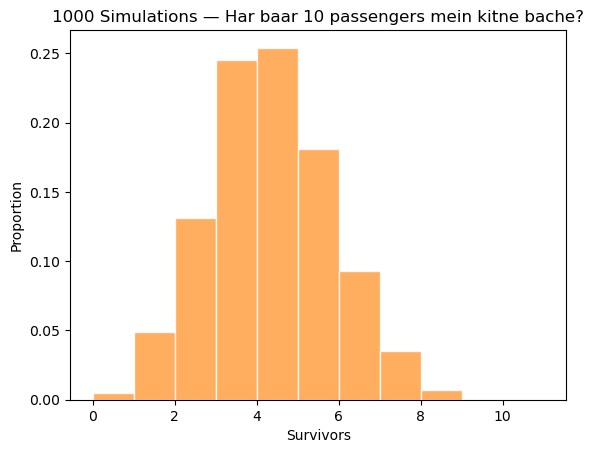

In [64]:
# 1000 baar 10 passengers ka experiment
simulations = binom.rvs(1000)

print(f"Average survivors per group : {simulations.mean():.2f}")
print(f"Expected (n×p)              : {n*p:.2f}")

# Plot
plt.hist(simulations, bins=range(0, 12),
         color='#ff9f43', edgecolor='white',
         alpha=0.85, density=True)
plt.title('1000 Simulations — Har baar 10 passengers mein kitne bache?')
plt.xlabel('Survivors')
plt.ylabel('Proportion')
plt.show()

NORMAL DISTRIBUTION 

In [66]:
age_data = df['age'].dropna()

In [73]:
mu    = age_data.mean()  
sigma = age_data.std()    

print(f"(Mean)    = {mu:.2f}")     
print(f" (Std Dev) = {sigma:.2f}") 

(Mean)    = 29.70
 (Std Dev) = 14.53


In [74]:
normal = stats.norm(mu, sigma)

In [75]:
print(f"P(age < 30) = {normal.cdf(30):.4f}")  
print(f"P(age > 50) = {1 - normal.cdf(50):.4f}") 
print(f"P(20 < age < 40) = {normal.cdf(40) - normal.cdf(20):.4f}") 

P(age < 30) = 0.5083
P(age > 50) = 0.0811
P(20 < age < 40) = 0.5087


In [76]:
# 68% rule — μ ± 1σ
p_68 = normal.cdf(mu + sigma) - normal.cdf(mu - sigma)
print(f"μ ± 1σ mein data = {p_68*100:.1f}%") 

# 95% rule — μ ± 2σ
p_95 = normal.cdf(mu + 2*sigma) - normal.cdf(mu - 2*sigma)
print(f"μ ± 2σ mein data = {p_95*100:.1f}%")  

# 99.7% rule — μ ± 3σ
p_99 = normal.cdf(mu + 3*sigma) - normal.cdf(mu - 3*sigma)
print(f"μ ± 3σ mein data = {p_99*100:.1f}%") 

μ ± 1σ mein data = 68.3%
μ ± 2σ mein data = 95.4%
μ ± 3σ mein data = 99.7%


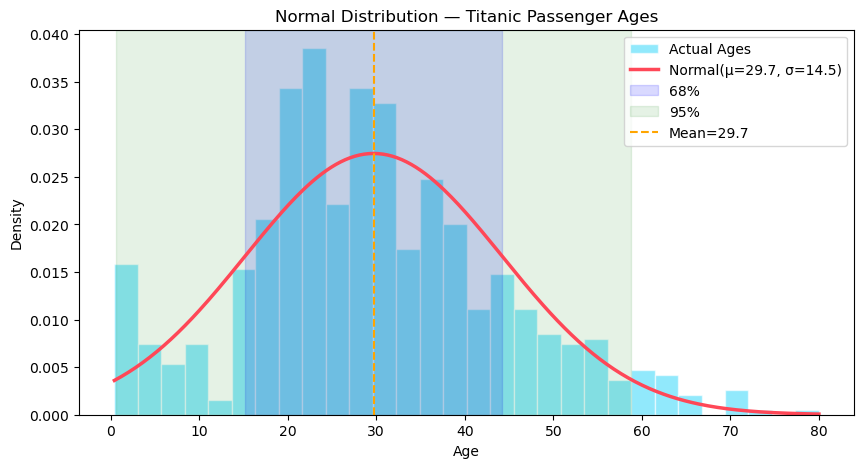

In [ ]:
plt.figure(figsize=(10, 5))

# Actual data histogram
plt.hist(age_data, bins=30, density=True,
         color='#48dbfb', alpha=0.6,
         edgecolor='white',
         label='Actual Ages')

# Normal curve
x = np.linspace(age_data.min(), age_data.max(), 300)
plt.plot(x, normal.pdf(x),
         color='#ff4757', linewidth=2.5,
         label=f'Normal(μ={mu:.1f}, σ={sigma:.1f})')

# 3 ranges shade 
plt.axvspan(mu-sigma, mu+sigma,   alpha=0.15, color='blue', label='68%')
plt.axvspan(mu-2*sigma, mu+2*sigma, alpha=0.10, color='green', label='95%')
plt.axvline(mu, color='orange', linestyle='--', label=f'Mean={mu:.1f}')

plt.title('Normal Distribution — Titanic Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

 Poisson Distribution

In [78]:
# Family size banao — SibSp + Parch
df['FamilySize'] = df['sibsp'] + df['parch']

# λ = average family size
lam = df['FamilySize'].mean()
print(f"λ (lambda) = {lam:.4f}") 

λ (lambda) = 0.9046


In [ ]:
poisson = stats.poisson(lam)

# Basic stats
print(f"Mean     = {poisson.mean():.4f}")   
print(f"Variance = {poisson.var():.4f}")    

Mean     = 0.9046
Variance = 0.9046


In [80]:
# Exactly 0 family members
print(f"P(X=0) = {poisson.pmf(0):.4f}") 

# Exactly 1 member
print(f"P(X=1) = {poisson.pmf(1):.4f}")

# 3 ya zyada members
print(f"P(X>=3) = {1 - poisson.cdf(2):.4f}")


P(X=0) = 0.4047
P(X=1) = 0.3661
P(X>=3) = 0.0636


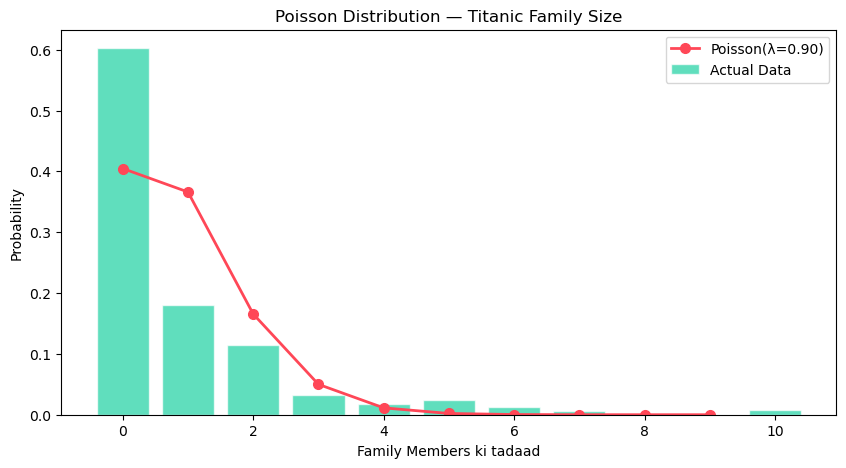

In [ ]:
k_values = np.arange(0, 10)
probs    = poisson.pmf(k_values)

# Actual data
actual = df['FamilySize'].value_counts(normalize=True).sort_index()

plt.figure(figsize=(10, 5))

# Actual bars
plt.bar(actual.index, actual.values,
        color='#1dd1a1', alpha=0.7,
        edgecolor='white', label='Actual Data')

# Theory line
plt.plot(k_values, probs, 'o-',
         color='#ff4757', linewidth=2,
         markersize=7, label=f'Poisson(λ={lam:.2f})')

plt.title('Poisson Distribution — Titanic Family Size')
plt.xlabel('Family Members count')
plt.ylabel('Probability')
plt.legend()
plt.show()

In [83]:
# 891 families simulate 
simulations = poisson.rvs(891)

print(f"Simulated average : {simulations.mean():.4f}")
print(f"Actual    average : {lam:.4f}")
print(f"single travellers  : {(simulations==0).sum()} out of 891")

Simulated average : 0.8900
Actual    average : 0.9046
single travellers  : 351 out of 891
